# Set up directories and download CIFAR-10 dataset (you only need to run this once)

In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# This prints the current working directory
import os
print('Current working directory: ', os.getcwd())

Current working directory:  /content


In [3]:
# You can use Linux commands like `pwd`, `cd` and `ls` to
# be sure about the path on which the Lab1 folder is
# Usually it should be in `/content/drive/MyDrive/labs/lab_1_2024_2025/`
!ls /content/drive/MyDrive/labs/

arrays	cifar-10-batches-py  lab_1_2024_2025  lab_2_2024_2025


In [ ]:
# Project's location path to `FOLDERPATH` variable.
FOLDERPATH = '/content/drive/MyDrive/labs/lab_1_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.insert(1, FOLDERPATH)

In [5]:
# This downloads CIFAR-10 dataset to your Drive
# if it doesn't already exist. Uncomment to run!
%cd {FOLDERPATH + '/engine/datasets/'}
!bash get_datasets.sh "cifar-10-batches-py"

/content/drive/MyDrive/labs/lab_1_2024_2025/engine/datasets


In [6]:
# Move the dataset to the `labs/` folder after downloading
import shutil
shutil.move(FOLDERPATH + '/engine/datasets/cifar-10-batches-py', '/content/drive/MyDrive/labs/')

Error: Destination path '/content/drive/MyDrive/labs/cifar-10-batches-py' already exists

In [6]:
# Verify the dataset is now in the `labs/` folder
!ls /content/drive/MyDrive/labs/

arrays	cifar-10-batches-py  lab_1_2024_2025  lab_2_2024_2025


In [7]:
# Having downloaded the dataset, let's change directory to
# Lab1 folder again to continue with the exercise
%cd {FOLDERPATH}

/content/drive/MyDrive/labs/lab_1_2024_2025


Find below the desired file structure:

```
labs
├── cifar-10-batches-py
│   ├── batches.meta
│   ├── ...
│   ├── test_batch
├── lab_0_2024_2025
│   ├── convolution.jpeg
│   ├── ...
│   ├── numerical_python_2.ipynb
├── lab_1_2024_2025
│   ├── engine
│   │   ├── classifiers/
│   │   ├── datasets/
│   │   ├── ...
│   ├── knn.ipynb
│   ├── ...
```

# k-Nearest Neighbor (k-NN)

## Run setup code

In [8]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
# This prints the current working directory
import os
print('Current working directory: ', os.getcwd())

Current working directory:  /content/drive/MyDrive/labs/lab_1_2024_2025


In [1]:
# This should be the location of Lab1 path
FOLDERPATH = '/content/drive/MyDrive/labs/lab_1_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Having downloaded the dataset, let's change directory to
# Lab1 folder again to continue with the exercise
%cd {FOLDERPATH}

/content/drive/MyDrive/labs/lab_1_2024_2025


In [2]:
# Run some setup code for this notebook.

import random
import numpy as np
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the notebook
# rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Pre-processing

In [9]:
from engine.data_utils import load_CIFAR10

# Load the raw CIFAR-10 data.
cifar10_dir = '/content/drive/MyDrive/labs/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


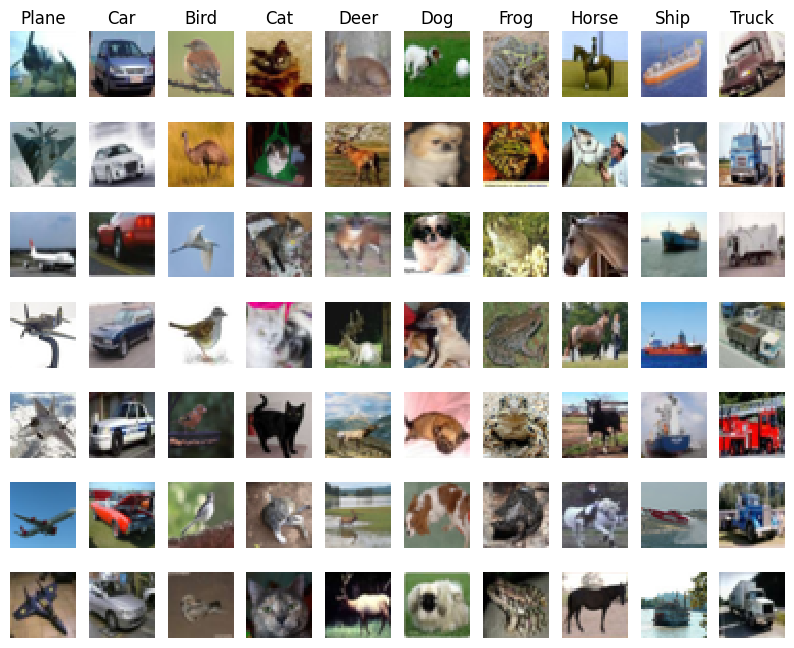

In [4]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls[:7])
plt.show()

Due to computation limitations, we choose to subsample the data for more efficient code execution. We choose to keep only ``5000`` images for training and ``500`` images for testing. We also reshape the ``3-dimensional`` *tensor* data to ``1-dimensional`` *vector* data. This is a preparation step for the k-NN classification we are about to run below.

In [10]:
# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

# Convert arrays uint8 -> float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


We can save these arrays (X_train, y_train, X_test, y_test) in a file format called ``.npy`` (numpy array), so that in case your runtime crashes, we can easily load them again WITHOUT having to load the whole dataset again. Let's have a look on how to do that!

In [8]:
# First, let's create a new folder called arrays
# inside the labs directory. Specify dir:
labs_dir = '/content/drive/MyDrive/labs'
arrays_dir = os.path.join(labs_dir, 'arrays')

# Create arrays directory
if not os.path.exists(arrays_dir):
    os.makedirs(arrays_dir)

# Save arrays in .npy files inside the new arrays dir
np.save(os.path.join(arrays_dir, 'X_train_knn.npy'), X_train)
np.save(os.path.join(arrays_dir, 'y_train_knn.npy'), y_train)
np.save(os.path.join(arrays_dir, 'X_test_knn.npy'), X_test)
np.save(os.path.join(arrays_dir, 'y_test_knn.npy'), y_test)

# Check that arrays are indeed saved
os.listdir(arrays_dir)

['full_X_train.npy',
 'full_y_train.npy',
 'full_X_test.npy',
 'full_y_test.npy',
 'X_train_knn.npy',
 'y_train_knn.npy',
 'y_test_knn.npy',
 'X_test_knn.npy']

## Load .npy files

Now, We can use the following coding snippet in case the runtime crashes to easily load these arrays.

In [ ]:
# Specify labs dir again, so that arrays dir is
# automatically retrieved and arrays can be loaded from it
labs_dir = '/content/drive/MyDrive/labs'
arrays_dir = os.path.join(labs_dir, 'arrays')

# Load arrays if needed. Uncomment to use!
X_train = np.load(os.path.join(arrays_dir, 'X_train_knn.npy'))
y_train = np.load(os.path.join(arrays_dir, 'y_train_knn.npy'))
X_test = np.load(os.path.join(arrays_dir, 'X_test_knn.npy'))
y_test = np.load(os.path.join(arrays_dir, 'y_test_knn.npy'))

# Num of samples for training and test
num_training = X_train.shape[0]
num_test = X_test.shape[0]

## Train k-NN classifier, Compute distance (two loops)

The kNN classifier consists of two stages:

- During training, the classifier takes the training data and simply remembers it
- During testing, kNN classifies every test image by comparing to all training images and transfering the labels of the k most similar training examples
- The value of k is cross-validated

In [11]:
from engine.classifiers.k_nearest_neighbor import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

We would now like to classify the test data with the kNN classifier. Recall that we can break down this process into two steps:

1. First we must compute the distances between all test examples and all train examples.
2. Given these distances, for each test example we find the k nearest examples and have them vote for the label

Lets begin with computing the distance matrix between all training and test examples. For example, if there are ``Ntr`` training examples and ``Nte`` test examples, this stage should result in a ``Nte x Ntr`` matrix where each element ``(i,j)`` is the distance between the ``i-th`` test and ``j-th`` train example.

We implement the function compute_distances_two_loops in engine/classifiers/k_nearest_neighbor.py that uses a (very inefficient) double loop over all pairs of (test, train) examples and computes the distance matrix one element at a time.

In [12]:
# Open engine/classifiers/k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists_two = classifier.compute_distances_two_loops(X_test)
print(dists_two.shape)

(500, 5000)


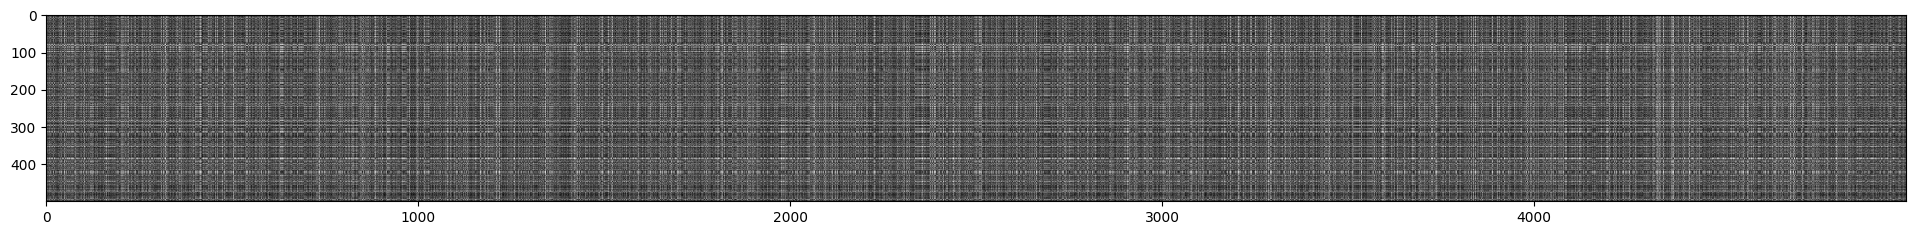

In [13]:
# We can also visualize the distance matrix: each row is a single test example and
# its distances to training examples

f = plt.figure(figsize=(24,4))
plt.imshow(dists_two, interpolation='none')

The shape of the distance matrix is (500, 5000), where each row represents the distances of a sample in the test set from every sample in training set and each column represents the distances of a sample in the training set from all points in the test set, respectively. Each point in the dists matrix corresponds o the L2 distance, so if the distance between i-th test and j-th training points is high the color is brighter and represents the disimilarity between the points, while if the distance between the points is low, the points are closer and the color is darker, which reveals the similarity between the points. Thus, a dark row means that this test point is very similar to the most of training points and a bright row declares that this test point is disimilar to most of training points. Likewise, when column is dark, we have this training point to be verey similar to most of the samples in test set and, when a column is bright means that this training point is away from most of test points. Generally, how dark or bright is a row or column reflects to how similar or disimilar a data point is(either if it is in training or test set) compared to the other dataset.

1. Bright/Dark Rows:
Bright Rows: In general, it can be stated that test sample is essentially different from most training samples.
Dark Rows: The general presentation of the test sample identifies it with many of the training samples suggesting that it represents a well-represented class.
2. Bright/Dark Columns:
Bright Columns: Training sample may be very dissimilar to most test samples possibly it’s an out of sample value.
Dark Columns: Relative distance of training sample to many test samples show that the training sample belongs to a general class.
This enables the definition of how well the test samples share similarity with the training data besides identifying cases of outlying or over-projection.





## Predict Labels



Let's go again back to `engine/classifiers/k_nearest_neighbor.py` and implement the function `predict_labels`. This function should take as input the distance matrix between test and training points and output a label for each test point.

In [14]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists_two, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


We should expect to see approximately `27%` accuracy (if more, then even better). Now lets try out a larger `k`, say `k = 5`:

In [15]:
y_test_pred = classifier.predict_labels(dists_two, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


We get a slightly better performance than with `k = 1`. If not, it's still fine!



Apart from L2 distance, we can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$,
the mean $\mu$ across all pixels over all images is $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$

The general standard deviation $\sigma$ is defined similarly.

Subtracting the mean $\mu$,

$$
\tilde{p}_{ij}^{(k)} = p_{ij}^{(k)} - \mu
$$

will not change the performance of the k-Nearest Neighbor classifier, as the mean from all pixel values will just shift all the points in the feature space by the same amount. Even if the absolute pixel values change by the mean for each point, the distances between points will remain unchanged.

Mathematically:

$$
L1 = \sum_{i,j} \left| \left(p_{ij}^{(k)} - \mu\right) - \left(p_{ij}^{(l)} - \mu\right) \right|
= \sum_{i,j} \left| p_{ij}^{(k)} - p_{ij}^{(l)} \right|
$$

Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$ not only changes pixel values, but also changes the distance between points. Therefore, the $L1$ distance changes, and this influences the performance of the classifier, usually improving it through normalization/standardization.

Mathematically:

$$
L1 = \sum_{i,j} \left| \frac{p_{ij}^{(k)} - \mu}{\sigma} - \frac{p_{ij}^{(l)} - \mu}{\sigma} \right|
= \frac{\sum_{i,j} \left| \tilde{p}_{ij}^{(k)} - \tilde{p}_{ij}^{(l)} \right|}{\sigma}
$$

## Compute distance (one loop)

In [16]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
difference = np.linalg.norm(dists_two - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

One loop difference was: 0.000000
Good! The distance matrices are the same


## Compute distance (no loops)



Again in `engine/classifiers/k_nearest_neighbor.py`. Let's implement the function `compute_distances_no_loops` that uses the fully vectorized version.

In [17]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists_two - dists, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


In [ ]:
# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# We should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop.
# Also, if a slow-down is observed from one loop to no loops, that's fine.

Two loop version took 38.631641 seconds
One loop version took 51.916226 seconds
No loop version took 1.031303 seconds


## k-fold cross validation

### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value ``k = 5`` arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

We split up the training data into folds and perform k-fold cross validation to find the best value of k.

In [ ]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}


from sklearn.metrics import accuracy_score  # We use accuracy_score to find the accuracy

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):

        X_val_fold = X_train_folds[fold]
        y_val_fold = y_train_folds[fold]


        X_train_fold = np.vstack([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_train_fold = np.hstack([y_train_folds[i] for i in range(num_folds) if i != fold])


        classifier = KNearestNeighbor()
        classifier.train(X_train_fold, y_train_fold)


        dists = classifier.compute_distances_no_loops(X_val_fold)
        y_val_pred = classifier.predict_labels(dists, k=k)


        accuracy = np.mean(y_val_pred == y_val_fold)
        k_to_accuracies[k].append(accuracy)



# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

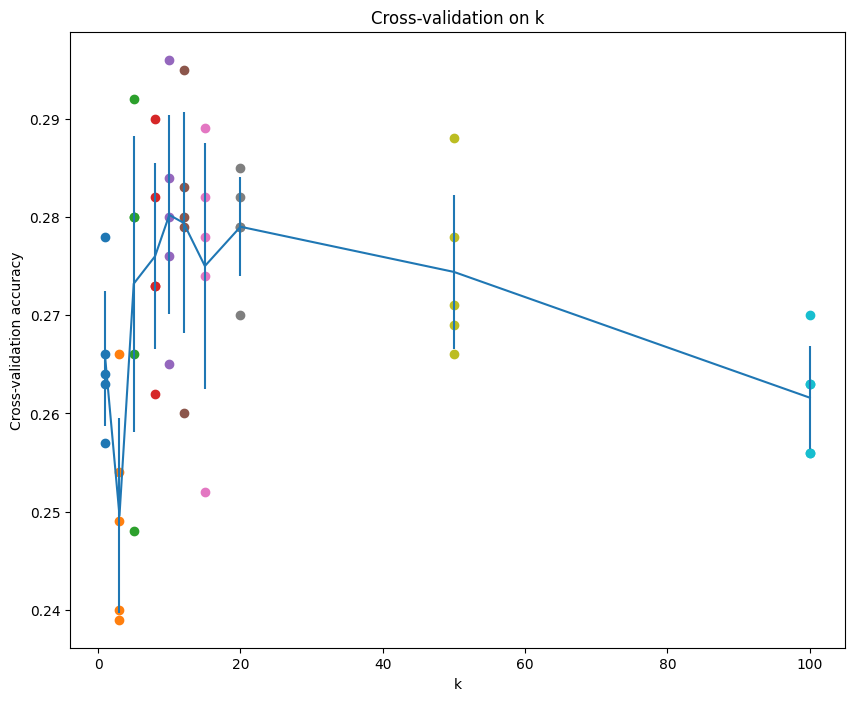

In [20]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [ ]:
# Based on the cross-validation results above, choose the best value for k,
# retrain the classifier using all the training data, and test it on the test
# data. We should be able to get above 28% accuracy on the test data.
best_k = 10

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 141 / 500 correct => accuracy: 0.282000


Some general observations:

In general, the decision boundary produced by a k-Nearest Neighbor classifier is non-linear.

For 1-NN, the training error is typically very low because the classifier essentially memorizes the training examples. As the value of `k` increases, the training error may also increase, since each prediction is based on a larger group of neighbors instead of only the closest training point.

However, 1-NN usually does not generalize as well to unseen data. Since it fits the training set very closely, it can overfit and become sensitive to noise or individual examples. Using a larger value of `k` can often reduce this overfitting by making predictions depend on several nearby samples rather than a single one.

As shown earlier in the notebook, finding nearest neighbors requires computing the distance between each test example and all training examples. Therefore, increasing the size of the training set also increases the time needed to compute distances and classify each test image.

Next, we randomly select one image from each of the 10 CIFAR-10 test classes. For each selected test image, we use the k-Nearest Neighbor classifier to find and display the 10 closest images from the training set.

For each selected test image:

- The 10 nearest training images are displayed according to their feature-space distances.
- The predicted class is shown below each retrieved image.
- A green border is used when the retrieved image belongs to the same class as the selected test image.
- A red border is used when the retrieved image belongs to a different class.

This visualization helps us inspect how well the k-NN classifier retrieves visually or semantically similar images from the training set.

This task allows us to visually inspect how well the k-NN classifier performs in "retrieving" images.

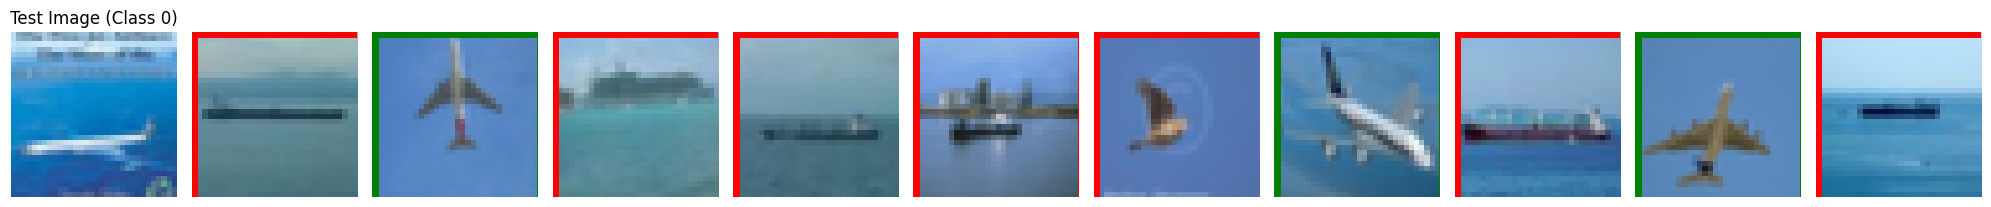

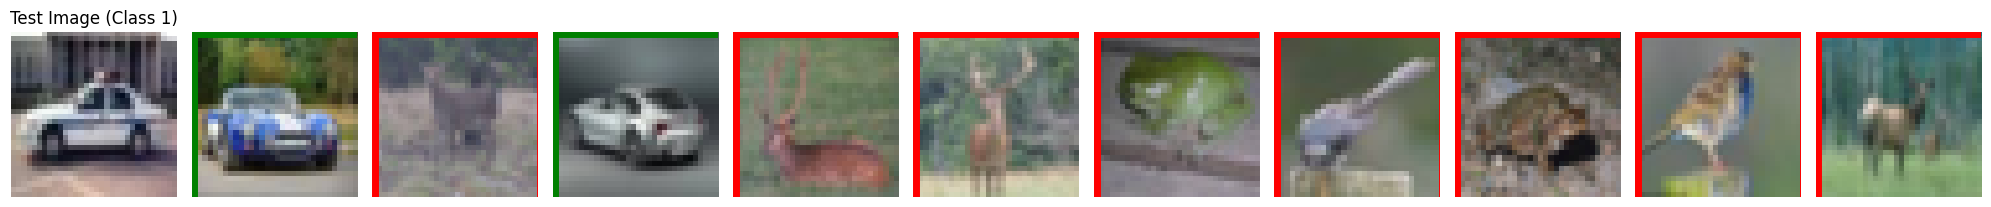

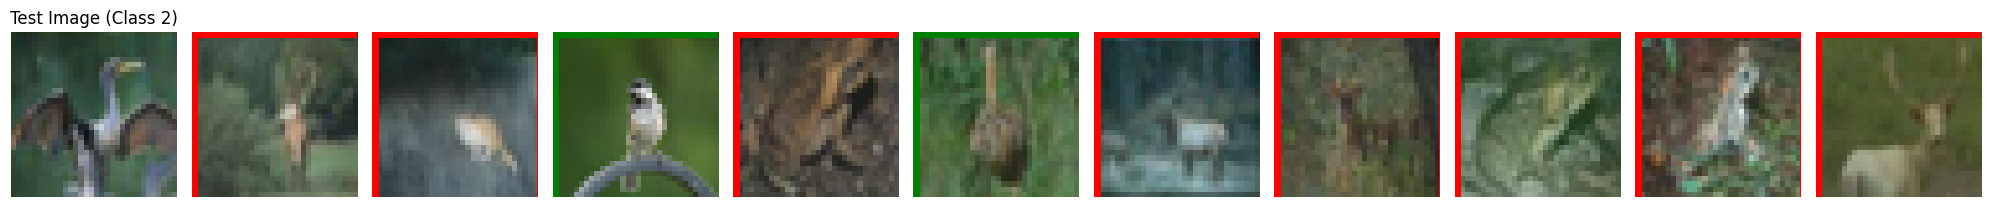

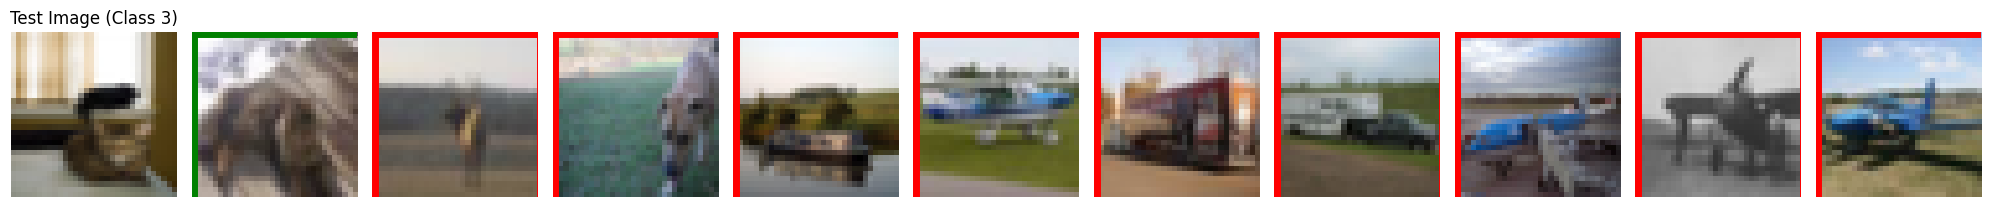

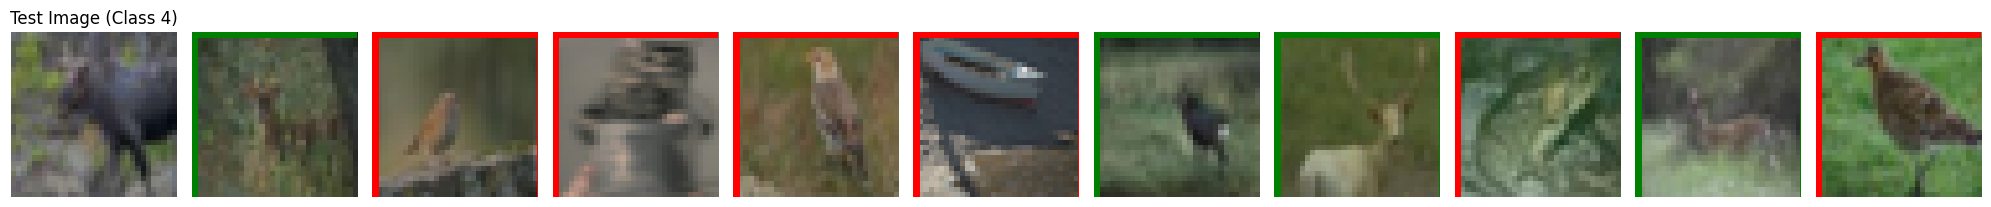

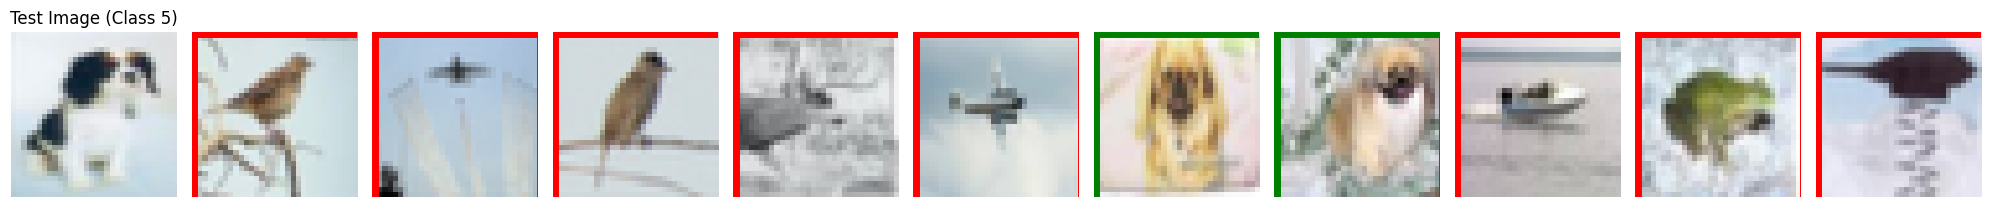

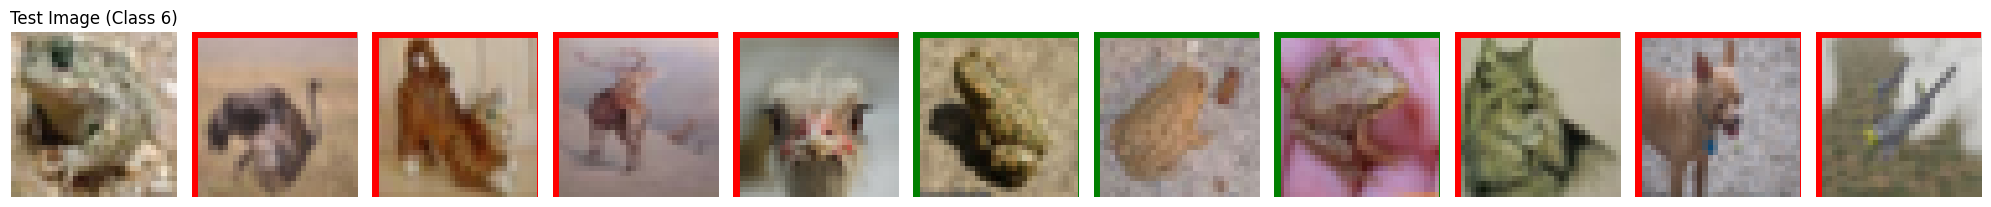

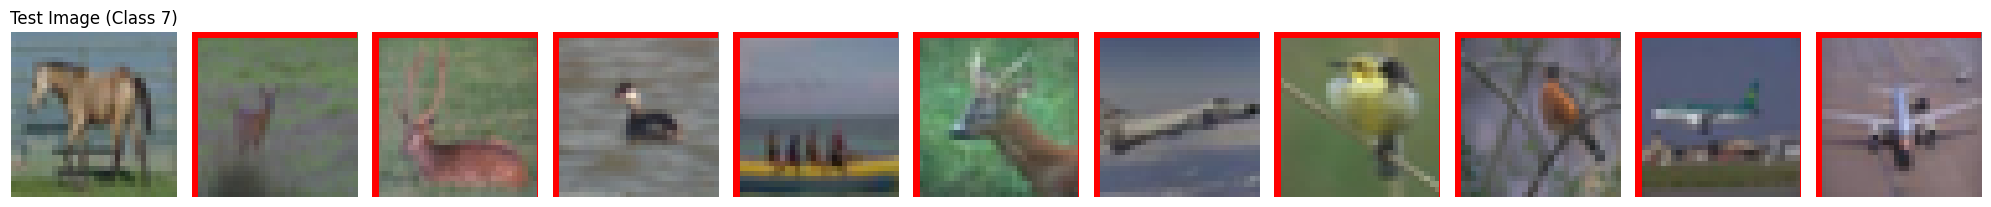

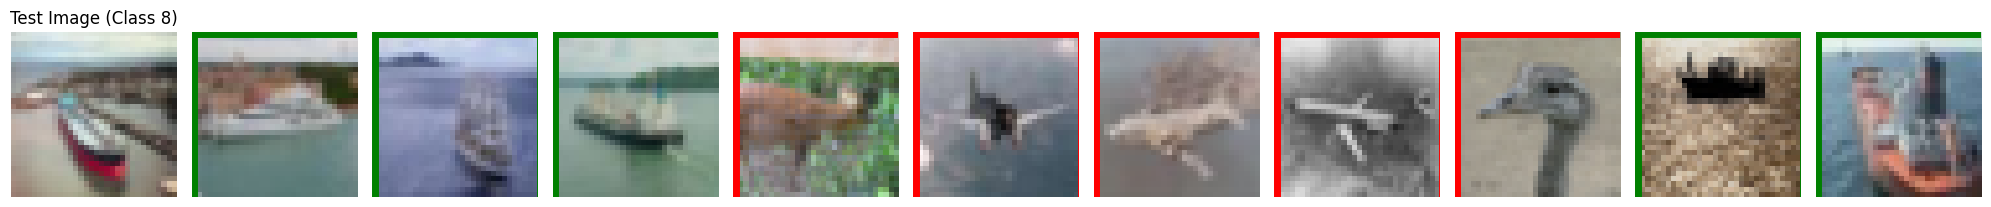

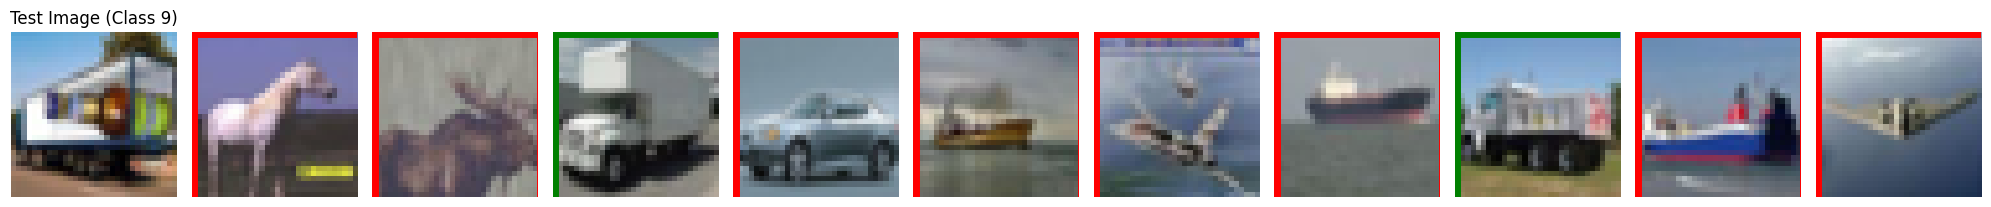

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_nearest_neighbors(classifier, X_train, y_train, X_test, y_test, num_classes=10, num_neighbors=10):

    for label in range(num_classes):

        idx = np.where(y_test == label)[0]
        random_idx = np.random.choice(idx)
        test_image = X_test[random_idx]


        dists = classifier.compute_distances_two_loops(test_image.reshape(1, -1))

        closest_idxs = np.argsort(dists[0])[:num_neighbors]


        fig, axes = plt.subplots(1, num_neighbors + 1, figsize=(20, 5))


        axes[0].imshow(test_image.reshape(32, 32, 3).astype('uint8'))
        axes[0].set_title(f"Test Image (Class {label})")
        axes[0].axis('off')

        for i in range(num_neighbors):
            train_image = X_train[closest_idxs[i]]
            predicted_label = y_train[closest_idxs[i]]
            correct = (predicted_label == label)

            axes[i + 1].imshow(train_image.reshape(32, 32, 3).astype('uint8'))
            axes[i + 1].axis('off')


            color = 'green' if correct else 'red'
            rect = patches.Rectangle((0, 0), 32, 32, linewidth=5, edgecolor=color, facecolor='none')
            axes[i + 1].add_patch(rect)

        plt.tight_layout()
        plt.show()

visualize_nearest_neighbors(classifier, X_train, y_train, X_test, y_test)


In the previous visualization, we evaluated how well the k-NN classifier with L2 distance retrieves the 10 nearest training images for one randomly selected test image from each CIFAR-10 class. If we used these retrieved images for classification with `k = 10`, the predicted label would be the class that appears most frequently among the 10 nearest neighbors.

Some qualitative observations from the results:

Retrieval can fail for several reasons.

First, different classes may have similar visual or morphological characteristics. For example, some deer images may look similar to cats or dogs because the animals can share similar body shapes, sizes, poses, or colors. Similarly, airplanes and ships may sometimes appear visually similar, especially when the image contains a large blue background. In these cases, k-NN may retrieve images from the wrong class.

Second, the background can strongly affect the nearest-neighbor results. Images with blue backgrounds may correspond to either sky or sea, which can confuse classes such as airplanes and ships. Similarly, animal images often contain green natural backgrounds, so the classifier may focus more on the background than on the actual object. This can lead to incorrect retrievals.

Third, viewpoint and pose can also cause mistakes. A car viewed from a certain angle may look similar to a truck, and a ship from a specific viewpoint may resemble an airplane. Since k-NN compares images directly in pixel space, changes in orientation, pose, or camera angle can significantly affect the retrieved neighbors.

Retrieval works better in cases where the nearest images share strong visual patterns with the query image.

For example, images from the same object family, such as cars and trucks or cats and dogs, often share similar shapes and textures. When the visual appearance is consistent, k-NN can retrieve relevant examples more effectively. It also works better when objects from different classes are visually very different, such as a frog compared with a ship or an airplane compared with a cat. In these cases, the pixel-level differences are large enough for k-NN to separate the classes more easily.

However, L2 distance only measures similarity based on raw pixel values. It does not understand the semantic meaning of an image. The classifier does not know which pixels correspond to the object and which belong to the background. As a result, it may classify an airplane as a ship because both images contain large blue regions, or it may confuse a cat with a dog because their shapes and textures are similar.

Overall, L2 distance mainly captures low-level visual properties such as color, texture, brightness, and approximate shape. It does not capture higher-level concepts such as object identity, scene context, or semantic meaning. To learn more meaningful image representations, more advanced models such as convolutional neural networks are needed.

In the current implementation, the `compute_distances_two_loops()` function computes the L2 distance between every test image and every training image. We now modify the function in `engine/classifiers/k_nearest_neighbor.py` so that it uses L1 distance, also known as Manhattan or taxicab distance, instead of L2 distance.

This requires computing the sum of the absolute differences between corresponding elements of the two points.


In [ ]:
# Having implemented compute_distances_two_loops function in engine/classifiers/k_nearest_neighbor.py we test our implementation.
dists_two = classifier.compute_distances_two_loops(X_test,dist="L1")
print(dists_two.shape)

(500, 5000)


In [24]:
# Now run again the function predict_labels.
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists_two, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 145 / 500 correct => accuracy: 0.290000


We observe that the k-NN classifier with L1 distance performs slightly better.

After modifying the `compute_distances_two_loops()` function to compute L1 distance, we reuse the same visualization procedure as before. Specifically, we randomly select one test image from each CIFAR-10 class and display the 10 closest training images according to the L1 distance.

This allows us to compare the retrieval behavior of L1 distance with the previous L2-based results and visually inspect whether the nearest neighbors are more consistent with the true class of each selected test image.

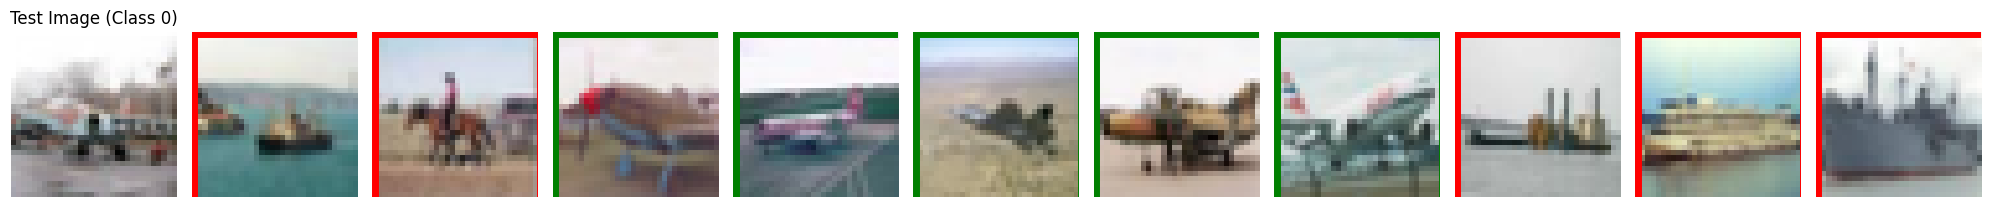

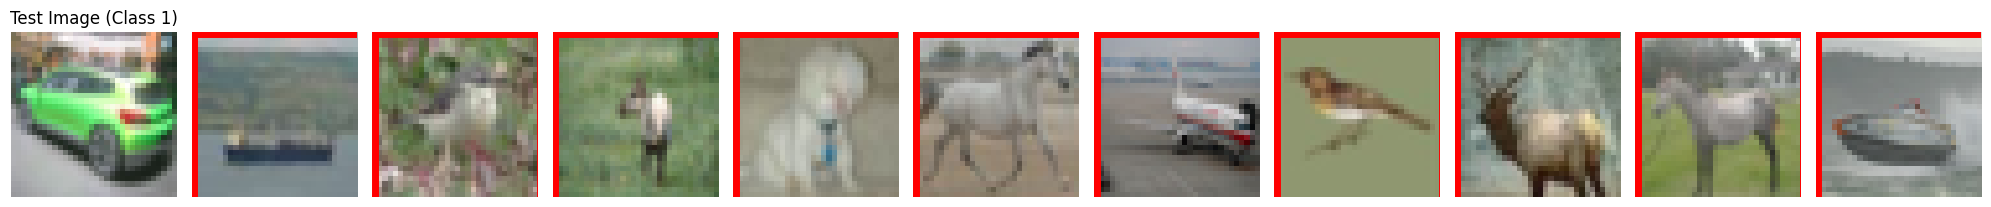

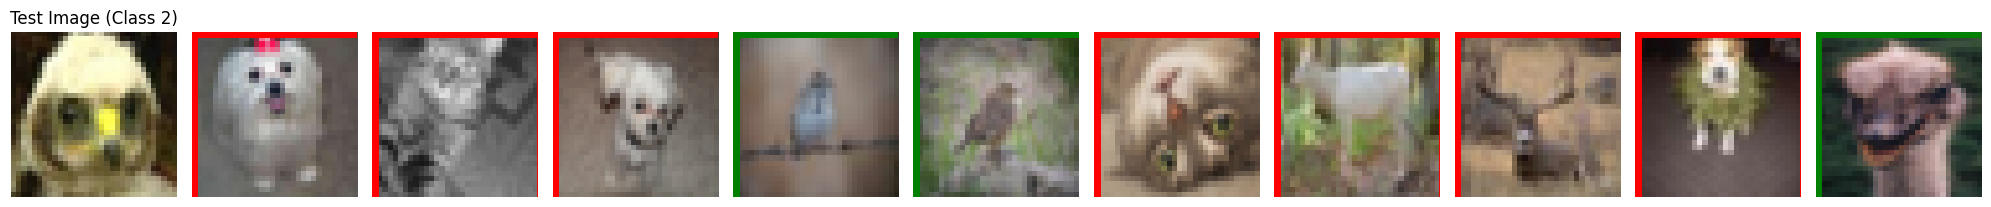

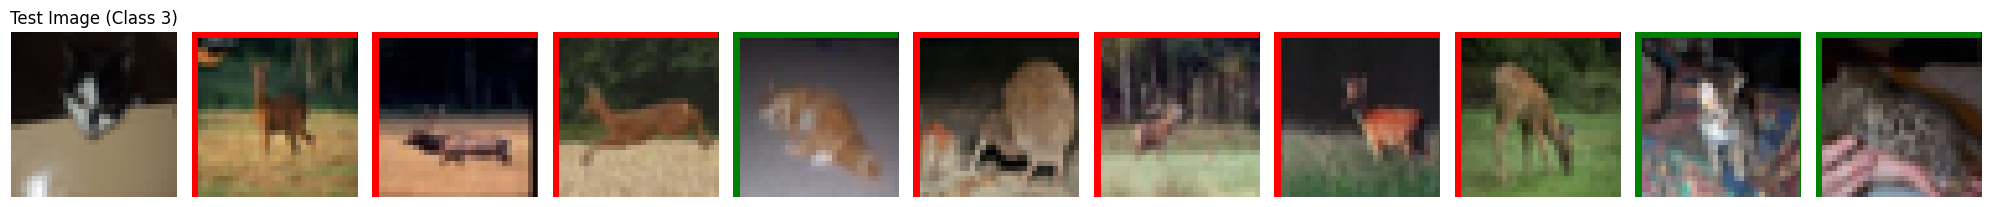

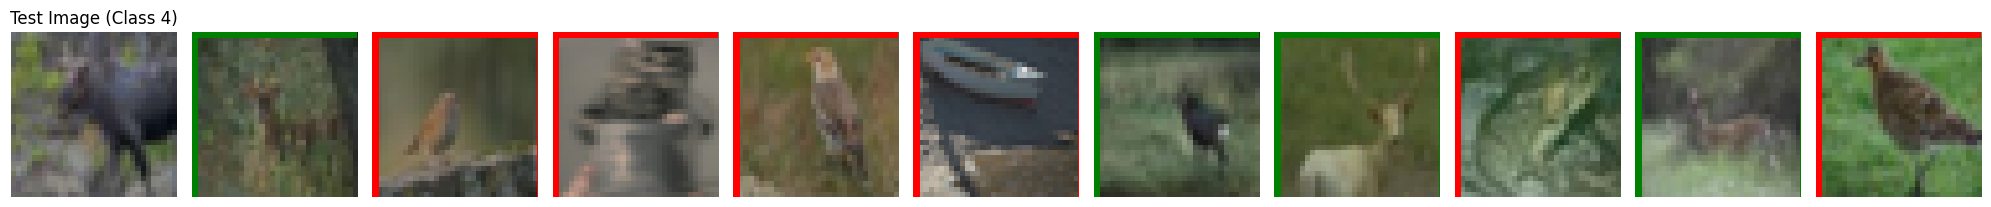

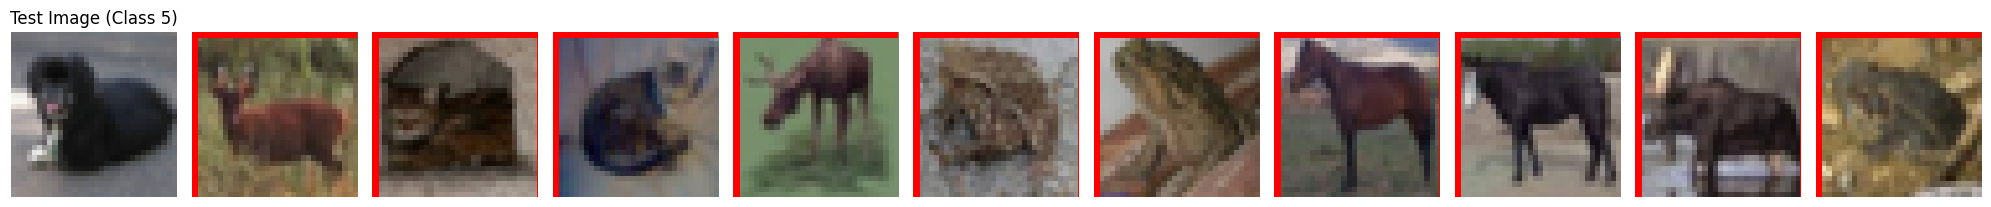

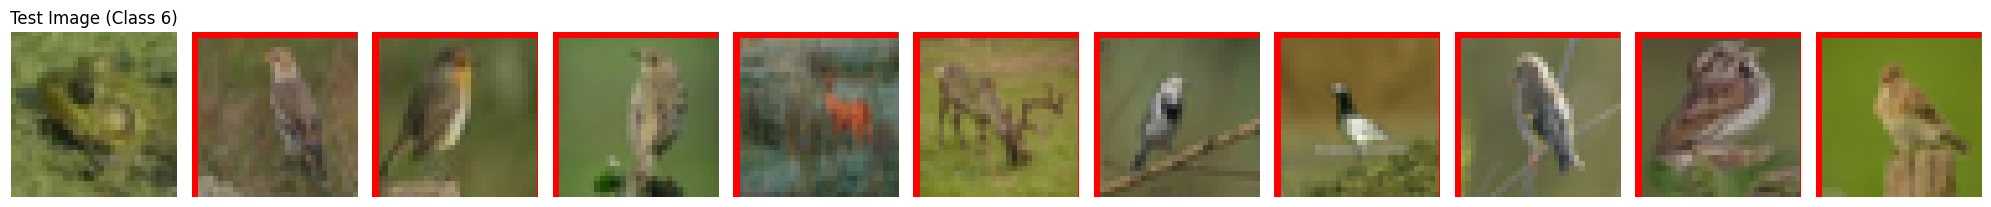

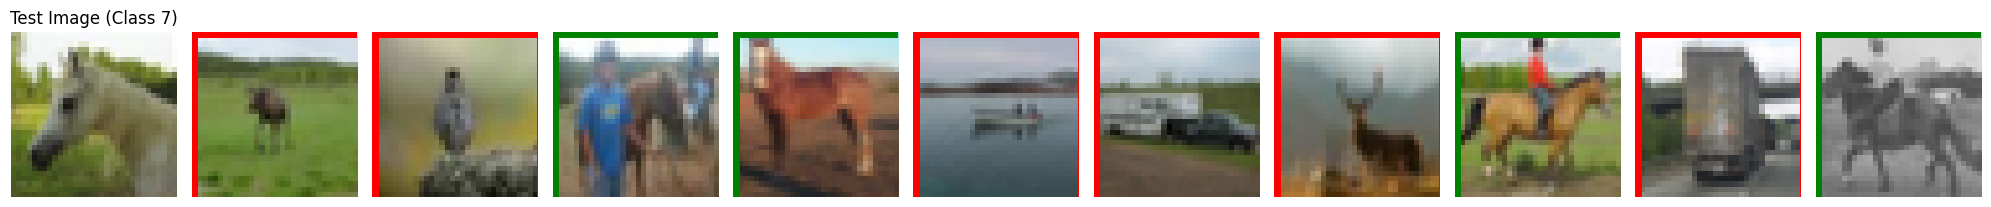

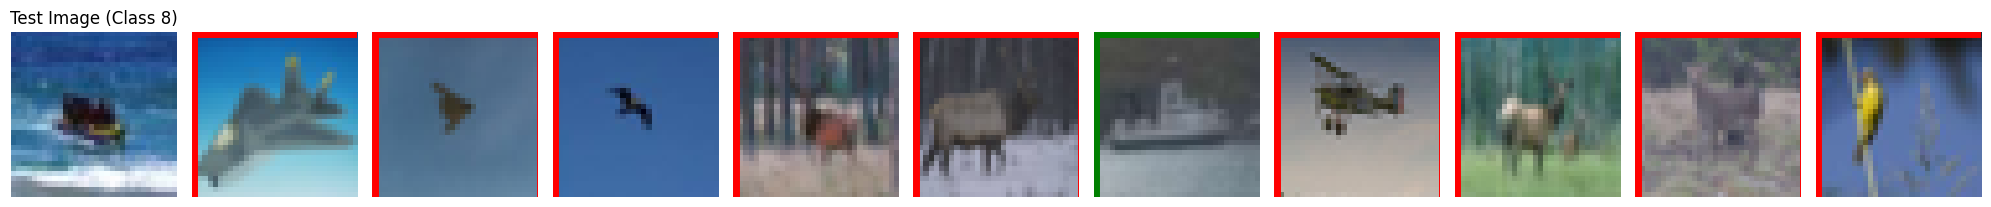

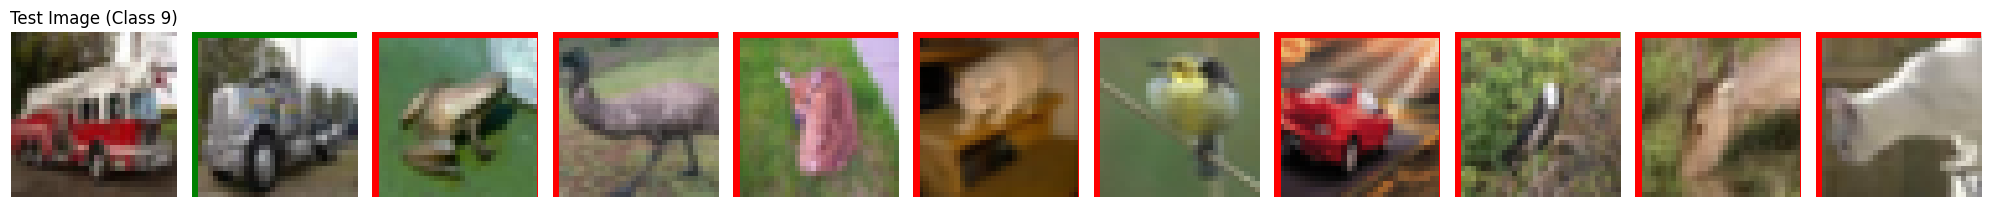

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_nearest_neighbors(classifier, X_train, y_train, X_test, y_test, num_classes=10, num_neighbors=10):

    for label in range(num_classes):

        idx = np.where(y_test == label)[0]
        random_idx = np.random.choice(idx)
        test_image = X_test[random_idx]


        dists = classifier.compute_distances_two_loops(test_image.reshape(1, -1))

        closest_idxs = np.argsort(dists[0])[:num_neighbors]


        fig, axes = plt.subplots(1, num_neighbors + 1, figsize=(20, 5))


        axes[0].imshow(test_image.reshape(32, 32, 3).astype('uint8'))
        axes[0].set_title(f"Test Image (Class {label})")
        axes[0].axis('off')

        for i in range(num_neighbors):
            train_image = X_train[closest_idxs[i]]
            predicted_label = y_train[closest_idxs[i]]
            correct = (predicted_label == label)

            axes[i + 1].imshow(train_image.reshape(32, 32, 3).astype('uint8'))
            axes[i + 1].axis('off')


            color = 'green' if correct else 'red'
            rect = patches.Rectangle((0, 0), 32, 32, linewidth=5, edgecolor=color, facecolor='none')
            axes[i + 1].add_patch(rect)

        plt.tight_layout()
        plt.show()

visualize_nearest_neighbors(classifier, X_train, y_train, X_test, y_test)

After visualizing the 10 nearest images using both L2 and L1 distance, we can compare the two retrieval results.

First, the L1-based k-NN classifier achieved slightly better accuracy than the L2-based version, with approximately 29% accuracy for L1 compared with 28.2% for L2. This is interesting because the L1 result was computed using the two-loop distance implementation, while the earlier L2 comparison used the no-loop implementation. The difference in accuracy is small, but it still suggests that L1 distance may perform slightly better in this experiment.

Based on the visual results, the predictions produced with L1 distance are quite similar to those obtained with L2 distance. Since the overall accuracy is still low, it is difficult to draw strong conclusions. However, one possible observation is that L1 distance may work slightly better when images share larger global shapes or color patterns, such as ships, airplanes, or frogs. This may happen because L1 distance captures broad differences between images without emphasizing very large pixel-level deviations as strongly as L2 distance does.

In some cases, L1 appears to retrieve images that are more semantically similar, especially when the overall structure and dominant colors are close. For example, rows with similar global object layouts or backgrounds may produce more consistent retrievals with L1.

On the other hand, L2 distance may sometimes be better when the object is more localized, zoomed in, or when finer visual details matter. For example, in classes such as deer, cats, or vehicles, local structures such as body shape, wheels, doors, lights, or object pose may be more important. Since L2 distance gives more weight to larger pixel-level differences, it can sometimes capture these more specific visual similarities better than L1.

In summary, L1 distance tends to focus more on overall/global differences, while L2 distance is more sensitive to detailed pixel-level differences. Therefore, L1 may be more useful when the goal is to retrieve images with similar global appearance, whereas L2 may be preferable when more detailed morphological similarities are important.

However, both distances are still based on raw pixel values, so neither method truly captures high-level semantic meaning. For deeper image understanding, more advanced feature extraction methods, such as convolutional neural networks, are more appropriate.